# MedMNIST-C

MedMNIST-C datasets here: https://zenodo.org/records/11471504

> \>10GB cada

MedMNIST datasets here: https://zenodo.org/records/10519652


Current result:


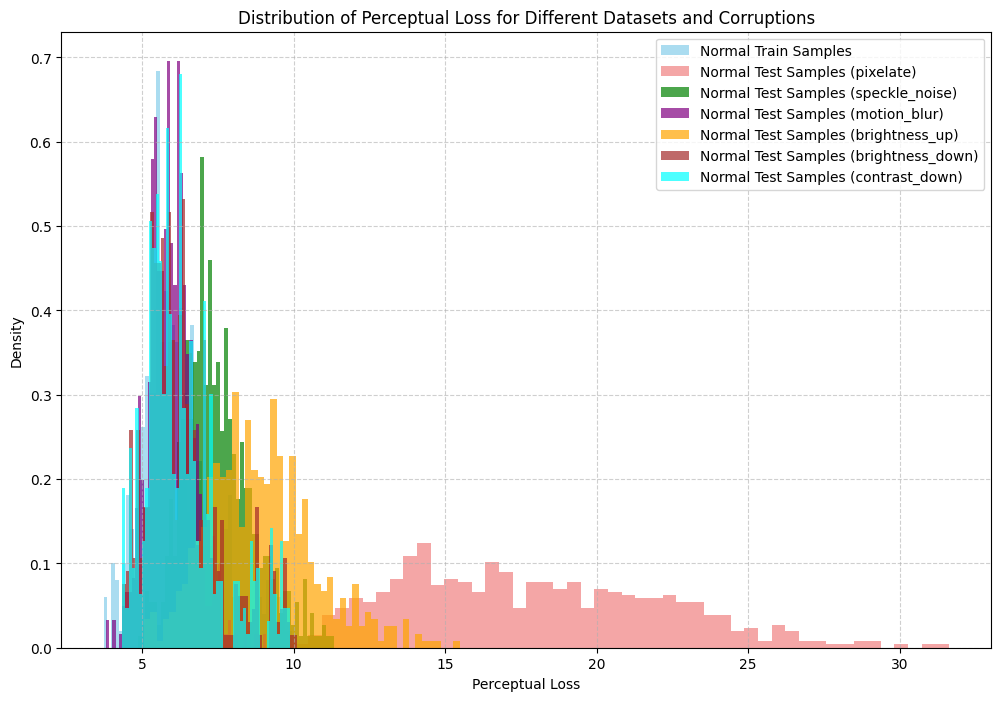

## SETUP

In [ ]:
!pip install medmnistc --quiet
!pip install torchmetrics --quiet
!sudo apt-get install libmagickwand-dev --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 50.3 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript
  gir1.2-rsvg-2.0 gsfonts imagemagick-6-common libdjvulibre-dev
  libdjvulibre-text libdjvulibre21 libfftw3-double3 libgdk-pixbuf-2.0-dev
  libgdk-pixbuf2.0-bin libgs9 libgs9-common libidn12 libijs-0.35 libjbig2dec0
  libjxr-tools libjxr0 liblcms2-dev liblqr-1-0 liblqr-1-0-dev
  libmagickcore-6-arch-config libmagickcore-6-headers libmagickcore-6.q16-6
  libmagickcore-6.q16-6-extra libmagickcore-6.q16-dev libmagickwand-6-headers
  libmagickwand-6.q16-6 libmagickwand-6.q16

In [ ]:
import medmnist
from medmnist import INFO, Evaluator
from medmnist.dataset import MedMNIST, PathMNIST, ChestMNIST, DermaMNIST, OCTMNIST, PneumoniaMNIST, RetinaMNIST, BreastMNIST

import os
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import utils
from torch import optim
from torch import device
from torch import inference_mode
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import models, transforms

import matplotlib.pyplot as plt

import tqdm
from timeit import default_timer as timer
from tqdm.auto import tqdm
from torchmetrics import ConfusionMatrix
import mlxtend
from mlxtend.plotting import plot_confusion_matrix
import numpy

from medmnistc.dataset import CorruptedMedMNIST
from medmnistc.eval import Evaluator
from medmnistc.corruptions.registry import CORRUPTIONS_DS

from torch.utils.data import DataLoader
from copy import deepcopy
from tqdm import tqdm

import timm
import os
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Subset

# set device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
# device

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mean = .5
std = .5


def contrast_stretching(tensor):
    # tensor: (C, H, W), values in [0, 1]
    min_val = tensor.amin(dim=(1,2), keepdim=True)
    max_val = tensor.amax(dim=(1,2), keepdim=True)
    stretched = (tensor - min_val) / (max_val - min_val + 1e-8)
    return stretched

## DATASET (MedMNIST-C and MedMNIST)

In [ ]:
# MedMNIST (train dataset)
# download and load data from official source

config = {
    # 'dataset' : 'breastmnist',
    # 'dataset' : 'retinamnist',
    # 'dataset' : 'pneumoniamnist', # Remove this line
    'dataset' : 'octmnist',
    'medmnist_path' : '/root/.medmnist', # Default MedMNIST download location
    # 'medmnistc_path' : '/content/medmnistc_corrupted_datasets' # Accessible location in Colab
    'medmnistc_path' : '/content/drive/MyDrive/Doutorado/MedMNIST'
}

# data_flag = 'breastmnist'
# data_flag = 'retinamnist'
# data_flag = 'pneumoniamnist'
data_flag = 'octmnist'
info = INFO[data_flag] # This line will cause an error if data_flag is not defined. We should use INFO['breastmnist'] directly.
DataClass = getattr(medmnist, info['python_class']) # This line will also cause an error.

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=.5, std=.5),
    transforms.Lambda(contrast_stretching)  # <-- Add contrast stretching here
])

# Data preparation
# transform = transforms.Compose([
#     transforms.Resize((64, 64)), # Resize to match autoencoder input
#     transforms.ToTensor(),
#     transforms.Lambda(contrast_stretching),  # <-- Add contrast stretching here
# ])

# Load data as RGB (3 channels)
# train_data = DataClass(split='train', transform=data_transform, download=True, as_rgb=True)
# train_data = DataClass(split='train', transform=data_transform, download=True)
# val_data = DataClass(split='val', transform=data_transform, download=True, as_rgb=True)
# test_data = DataClass(split='test', transform=data_transform, download=True, as_rgb=True)

# Directly use BreastMNIST and remove the dataset_name argument
# train_data = BreastMNIST(
#     # dataset_name = config['dataset'], # Remove this line
#     split='train', # Specify the split
#     transform=data_transform, # Apply the defined transform
#     download=True, # Set to True to download if not already present
#     root = config['medmnist_path'], # Use the path for original MedMNIST
#     # as_rgb = test_dataset_clean.as_rgb, # as_rgb is not a common argument for BreastMNIST, check docs if needed
#     mmap_mode='r', # Keep mmap_mode if desired
#     as_rgb = True,
#     size=224,
#     # norm_mean = mean, # Normalization is handled by the transform
#     # norm_std = std # Normalization is handled by the transform
#   )

# train_data = RetinaMNIST(
#     # dataset_name = config['dataset'], # Remove this line
#     split='train', # Specify the split
#     transform=data_transform, # Apply the defined transform
#     download=True, # Set to True to download if not already present
#     root = config['medmnist_path'], # Use the path for original MedMNIST
#     # as_rgb = test_dataset_clean.as_rgb, # as_rgb is not a common argument for BreastMNIST, check docs if needed
#     mmap_mode='r', # Keep mmap_mode if desired
#     as_rgb = True,
#     size=224,
#     # norm_mean = mean, # Normalization is handled by the transform
#     # norm_std = std # Normalization is handled by the transform
#   )

# train_data = PneumoniaMNIST(
#     # dataset_name = config['dataset'], # Remove this line
#     split='train', # Specify the split
#     transform=data_transform, # Apply the defined transform
#     download=True, # Set to True to download if not already present
#     root = config['medmnist_path'], # Use the path for original MedMNIST
#     # as_rgb = test_dataset_clean.as_rgb, # as_rgb is not a common argument for BreastMNIST, check docs if needed
#     mmap_mode='r', # Keep mmap_mode if desired
#     as_rgb = True,
#     size=224,
#     # norm_mean = mean, # Normalization is handled by the transform
#     # norm_std = std # Normalization is handled by the transform
#   )

train_data = OCTMNIST(
    # dataset_name = config['dataset'], # Remove this line
    split='train', # Specify the split
    transform=data_transform, # Apply the defined transform
    download=True, # Set to True to download if not already present
    root = config['medmnist_path'], # Use the path for original MedMNIST
    # as_rgb = test_dataset_clean.as_rgb, # as_rgb is not a common argument for BreastMNIST, check docs if needed
    mmap_mode='r', # Keep mmap_mode if desired
    as_rgb = True,
    size=224,
    # norm_mean = mean, # Normalization is handled by the transform
    # norm_std = std # Normalization is handled by the transform
  )

# train_data, test_data, val_data

############################################################
# NORMAL TRAIN DATA LOADER WITH 'NORMAL' CLASS ONLY
############################################################

# Get the indices of samples belonging to the 'normal, benign' class (label 1)
normal_train_indices = [i for i, (_, label) in enumerate(train_data) if label == 1]

# Create a Subset of the original dataset using these indices
normal_train_dataset = Subset(train_data, normal_train_indices)

# Create a new DataLoader for the filtered dataset
BATCH_SIZE = 128 # Use your desired batch size
normal_train_dataloader = DataLoader(dataset=normal_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Original dataset size: {len(train_data)}")
print(f"Filtered 'normal' train dataset size: {len(normal_train_dataset)}")
print(f"Filtered 'normal' train dataloader has {len(normal_train_dataloader)} batches.")

100%|██████████| 3.96G/3.96G [19:41<00:00, 3.35MB/s]


Original dataset size: 97477
Filtered 'normal' train dataset size: 10213
Filtered 'normal' train dataloader has 80 batches.


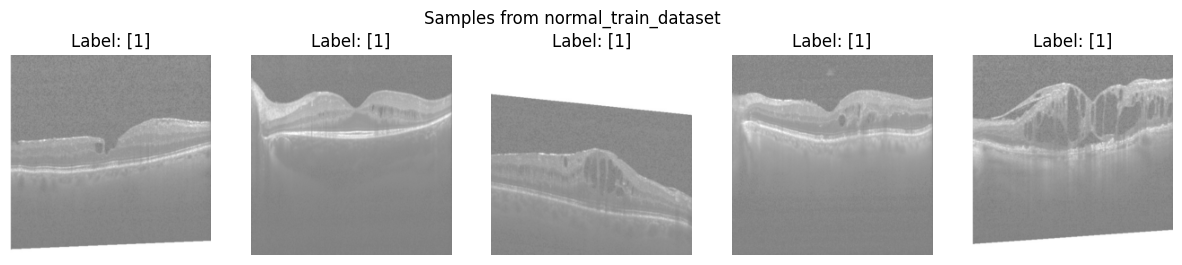

In [ ]:
import matplotlib.pyplot as plt
import torchvision

# Function to show multiple samples from a dataset (reusing the one defined earlier)
def show_samples(dataset, title, num_samples=5):
    plt.figure(figsize=(15, 3))
    plt.suptitle(title)
    for i in range(min(num_samples, len(dataset))):
        # Get one sample from the dataset
        # Since it's a Subset, indexing accesses the element within the subset
        image, label = dataset[i]

        # Ensure the image is a PyTorch Tensor with shape (C, H, W)
        if not isinstance(image, torch.Tensor):
            # If it's a PIL Image, convert to Tensor (already done by initial transform)
            # If it's a NumPy array, convert to Tensor
            image = torch.from_numpy(image)
            if image.ndim == 2:
                 image = image.unsqueeze(0) # Add channel dimension if grayscale

        # For visualization, we need to reverse the normalization and potentially permute dimensions
        # Assuming the images are 3 channels as_rgb=True and normalized with mean=0.5, std=0.5
        # Reverse normalization: image = image * std + mean
        mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1) # Reshape for broadcasting
        std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
        display_image = image * std + mean

        # Clamp values to be in [0, 1] in case of floating point inaccuracies
        display_image = torch.clamp(display_image, 0, 1)

        # Permute dimensions from (C, H, W) to (H, W, C) for matplotlib
        display_image = display_image.permute(1, 2, 0)

        # Convert to numpy array
        display_image = display_image.numpy()

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(display_image)
        plt.title(f"Label: {label}")
        plt.axis('off')

    plt.show()

# Display samples from the normal_train_dataset
show_samples(normal_train_dataset, "Samples from normal_train_dataset")

In [ ]:
# normal_train_dataset.dataset.size

In [ ]:
# Own corruptedMedMNIST implementation to change transform

class CorruptedMedMNIST(Dataset):
    def __init__(self,
                 dataset_name : str,
                 corruption : str,
                 norm_mean : list = [0.5],
                 norm_std : list = [0.5],
                 root : str = None,
                 as_rgb : bool = True,
                 mmap_mode : str = None):
        """
        Dataset class of CorruptedMedMNIST

        :param dataset_name: Name of the reference medmnist dataset.
        :param corruption: Name of the desired corruption.
        :param norm_mean: Normalization mean.
        :param norm_std: Normalization standard deviation.
        :param root: Root path of the generated corrupted data.
        :param as_rgb: Flag for RGB of Greyscale data.
        :param mmap_mode: Memory mapping of the file: {None, ‘r+’, ‘r’, ‘w+’, ‘c’}.
                          If not None, then memory-map the file, using the given mode
                          (see numpy.memmap for a detailed description of the modes).
                          Memory mapping is especially useful for accessing small
                          fragments of large files without reading the entire file into memory.
                          src: https://numpy.org/doc/stable/reference/generated/numpy.load.html

        This dataset class was greatly inspired from the MedMNIST APIs:
            https://github.com/MedMNIST/MedMNIST
        """

        super(CorruptedMedMNIST, self).__init__()

        self.dataset_name = dataset_name
        self.corruption = corruption
        self.root = root
        self.as_rgb = as_rgb

        if root is not None and os.path.exists(root):
            self.root = root
        else:
            raise RuntimeError(
                "Failed to setup the default `root` directory. "
                + "Please specify and create the `root` directory manually."
            )

        if not os.path.exists(os.path.join(self.root, self.dataset_name, f"{corruption}.npz")):
            print(os.path.join(self.root, self.dataset_name, f"{corruption}.npz"))
            raise RuntimeError(
                "Dataset not found."
            )

        npz_file = np.load(
            os.path.join(self.root, self.dataset_name, f"{corruption}.npz"),
            mmap_mode=mmap_mode,
        )

        self.imgs = npz_file["test_images"]
        self.labels = npz_file["test_labels"]
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=norm_mean, std=norm_std),
            transforms.Lambda(contrast_stretching)  # <-- Add contrast stretching here
        ])


    def __len__(self):
        return self.imgs.shape[0]


    def __getitem__(self, index):
        img, target = self.imgs[index], self.labels[index].astype(int)
        img = Image.fromarray(img)

        if self.as_rgb:
            img = img.convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, target

In [ ]:
# MedMNIST-C (test dataset)

# Create the directory for corrupted datasets if it doesn't exist
os.makedirs(config['medmnistc_path'], exist_ok=True)

# Load clean dataset
DataClass = getattr(medmnist, info['python_class'])

# corruptions = CORRUPTIONS_DS[config['dataset']]

corrupted_test_test = CorruptedMedMNIST(
    dataset_name = config['dataset'],
    # corruption = "pixelate",
    # corruption = "motion_blur",
    # corruption = "brightness_down",
    corruption = "contrast_down",
    # corruption = "speckle_noise",
    # corruption = "brightness_up", - do not exist for retina, instead, use gaussian
    # corruption = "jpeg_compression",
    # corruption = "gaussian_noise",
    root = config['medmnistc_path'],
    # as_rgb = test_dataset_clean.as_rgb,
    mmap_mode='r',
    norm_mean = mean,
    norm_std = std
  )

# Get dataloader
# test_loader = DataLoader(corrupted_test_test, batch_size=128, shuffle=False, num_workers=4, persistent_workers=True)

# test_loader.dataset

############################################################
# NORMAL CORRUPTED TEST DATA LOADER WITH 'NORMAL' CLASS ONLY
############################################################

from torch.utils.data import Subset

# Assuming corrupted_test_test is your original dataset loaded from medmnist
# and you want to filter the training data

# Get the indices of samples belonging to the 'normal, benign' class (label 1)
normal_test_indices = [i for i, (_, label) in enumerate(corrupted_test_test) if label == 1]

# Create a Subset of the original dataset using these indices
normal_test_dataset = Subset(corrupted_test_test, normal_test_indices)

# Create a new DataLoader for the filtered dataset
BATCH_SIZE = 128 # Use your desired batch size
normal_test_dataloader = DataLoader(dataset=normal_test_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Original dataset size: {len(corrupted_test_test)}")
print(f"Filtered 'normal' test dataset size: {len(normal_test_dataset)}")
print(f"Filtered 'normal' test dataloader has {len(normal_test_dataloader)} batches.")

Original dataset size: 5000
Filtered 'normal' test dataset size: 1250
Filtered 'normal' test dataloader has 10 batches.


array([[ 31,  25,  23, ..., 167, 167, 167],
       [ 36,  37,  30, ..., 167, 167, 167],
       [ 31,  40,  40, ..., 167, 167, 167],
       ...,
       [ 18,  17,  23, ...,  17,  20,  17],
       [ 20,  17,  20, ...,  15,  16,  16],
       [ 20,  16,  18, ...,  19,  23,  22]], dtype=uint8)
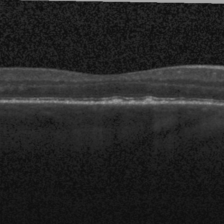

In [ ]:
corrupted_test_test.imgs[1]
# corrupted_test_test.imgs[157]
# corrupted_test_test.imgs[313]
# corrupted_test_test.imgs[469]

# corrupted_test_test.imgs[399]
# corrupted_test_test.imgs[1999]

In [ ]:
from torch.utils.data import Subset

# Assuming corrupted_test_test is available and contains 780 samples (5 severities * 156 samples)
# Assuming BATCH_SIZE is defined

# Determine the number of samples per severity level
# BREASTMNIST - 156
# samples_per_severity = 156 # Based on the original test set size
# RETINAMNIST - 400
# samples_per_severity = 400
# PNEUMONIAMNIST - 624
# samples_per_severity = 624
# OCTMNIST -
samples_per_severity = 1000


# Initialize a dictionary to store dataloaders for each severity level
normal_corrupted_test_dataloaders_by_severity = {}

print(f"Splitting dataset into {len(corrupted_test_test) // samples_per_severity} severity levels...")

# Iterate through the 5 severity levels
for severity_level in range(5):
    print(f"\nProcessing severity level {severity_level + 1}...")

    # Calculate the start and end indices for the current severity level
    start_index = severity_level * samples_per_severity
    end_index = start_index + samples_per_severity

    # Create a Subset for the current severity level
    severity_subset = Subset(corrupted_test_test, range(start_index, end_index))

    print(f"  Subset size for severity {severity_level + 1}: {len(severity_subset)}")

    # Filter the current severity subset to include only 'normal' samples (label 1)
    # We need to iterate through the actual dataset within the Subset to get labels
    normal_severity_indices_in_subset = [
        i for i, (_, label) in enumerate(severity_subset) if label == 1
    ]

    # Create a Subset of the severity_subset containing only normal samples
    normal_severity_dataset = Subset(severity_subset, normal_severity_indices_in_subset)

    print(f"  Filtered 'normal' dataset size for severity {severity_level + 1}: {len(normal_severity_dataset)}")

    # Create a DataLoader for the filtered normal severity dataset
    normal_severity_dataloader = DataLoader(
        dataset=normal_severity_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False # No need to shuffle for evaluation
    )

    # Store the dataloader in the dictionary
    normal_corrupted_test_dataloaders_by_severity[f'severity_{severity_level + 1}'] = normal_severity_dataloader

    print(f"  DataLoader for severity {severity_level + 1} has {len(normal_severity_dataloader)} batches.")

print("\nFinished creating dataloaders for normal samples at each severity level.")

# Example of accessing a dataloader for a specific severity:
# severity_1_dataloader = normal_corrupted_test_dataloaders_by_severity['severity_1']
# print(f"\nExample: DataLoader for Severity 1 has {len(normal_corrupted_test_dataloaders_by_severity['severity_1'])} batches.")

Splitting dataset into 5 severity levels...

Processing severity level 1...
  Subset size for severity 1: 1000
  Filtered 'normal' dataset size for severity 1: 250
  DataLoader for severity 1 has 2 batches.

Processing severity level 2...
  Subset size for severity 2: 1000
  Filtered 'normal' dataset size for severity 2: 250
  DataLoader for severity 2 has 2 batches.

Processing severity level 3...
  Subset size for severity 3: 1000
  Filtered 'normal' dataset size for severity 3: 250
  DataLoader for severity 3 has 2 batches.

Processing severity level 4...
  Subset size for severity 4: 1000
  Filtered 'normal' dataset size for severity 4: 250
  DataLoader for severity 4 has 2 batches.

Processing severity level 5...
  Subset size for severity 5: 1000
  Filtered 'normal' dataset size for severity 5: 250
  DataLoader for severity 5 has 2 batches.

Finished creating dataloaders for normal samples at each severity level.


In [ ]:
# corruptions = CORRUPTIONS_DS[config['dataset']]
# corruptions

## DeepSAM

### Architecture

In [ ]:
# Define the Autoencoder class with inplace=False for ReLU
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=False),  # <-- Ensure inplace=False
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.GroupNorm(num_groups=128, num_channels=128),  # or 1 group per channel (i.e., InstanceNorm)
            # nn.GroupNorm(num_groups=32, num_channels=128),

            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=False),  # <-- Ensure inplace=False
            nn.MaxPool2d(kernel_size=2, stride=2),
            # nn.GroupNorm(num_groups=16, num_channels=64),
            nn.GroupNorm(num_groups=64, num_channels=64),  # or 1 group per channel (i.e., InstanceNorm)

            nn.Conv2d(64, latent_dim, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=False),  # <-- Ensure inplace=False
            nn.MaxPool2d(kernel_size=2, stride=2)
            # nn.GroupNorm(num_groups=32, num_channels=32),  # or 1 group per channel (i.e., InstanceNorm)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(latent_dim, latent_dim, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=False),  # <-- Ensure inplace=False
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.BatchNorm2d(latent_dim),

            nn.Conv2d(latent_dim, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=False),  # <-- Ensure inplace=False
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=False),  # <-- Ensure inplace=False
            nn.Upsample(scale_factor=2, mode='nearest'),

            nn.Conv2d(128, 3, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


class MultiLayerFeatureExtractor(nn.Module):
    def __init__(self, vgg_features_sequential, selected_layers):
        super().__init__()
        self.selected_layers = selected_layers
        # The 'vgg_features_sequential' argument is ALREADY the Sequential module containing the features.
        # We don't need to access '.features' again.
        self.vgg_layers = vgg_features_sequential
        self.layer_mapping = {
            'block1_conv1': 0,  'block1_conv2': 2,
            'block2_conv1': 5,  'block2_conv2': 7,
            'block3_conv1': 10, 'block3_conv2': 12, 'block3_conv3': 14, 'block3_conv4': 16,
            'block4_conv1': 19, 'block4_conv2': 21, 'block4_conv3': 23, 'block4_conv4': 25,
            'block5_conv1': 28, 'block5_conv2': 30, 'block5_conv3': 32, 'block5_conv4': 34,
        }

    def forward(self, x):
        features = []
        layer_indices_to_extract = [self.layer_mapping[l] for l in self.selected_layers]
        for name, layer in enumerate(self.vgg_layers):
            x = layer(x)
            if name in layer_indices_to_extract:
                features.append(x)
        return features

class PerceptualLoss(nn.Module):
    def __init__(self, vgg_features_sequential, selected_layers, selected_layer_weights):
        super().__init__()
        self.feature_extractor = MultiLayerFeatureExtractor(vgg_features_sequential, selected_layers)
        self.selected_layer_weights = selected_layer_weights
        # Add a transform to resize images to 224x224 for VGG input
        self.resize_transform = transforms.Resize((224, 224), antialias=True)


    def forward(self, input, recon):
        # Resize inputs and reconstructions to 224x224 before passing through VGG
        input_resized = self.resize_transform(input)
        recon_resized = self.resize_transform(recon)

        mean = torch.tensor([0.485, 0.456, 0.406], device=input.device).view(1,3,1,1)
        std = torch.tensor([0.229, 0.224, 0.225], device=input.device).view(1,3,1,1)
        input_norm = (input_resized - mean) / std
        recon_norm = (recon_resized - mean) / std


        feats_input = self.feature_extractor(input_norm)
        feats_recon = self.feature_extractor(recon_norm)

        # Compute per-sample perceptual loss
        losses = []
        for f1, f2, w in zip(feats_input, feats_recon, self.selected_layer_weights):
            # # Compute per-sample MSE (no reduction)
            # mse = F.mse_loss(f1, f2, reduction='none')
            # # Average over all but batch dimension
            # mse = mse.view(mse.size(0), -1).mean(dim=1)

            # alternative to make equal to keras implementation
            mse = F.mse_loss(f1, f2, reduction='none')
            mse = mse.view(mse.size(0), -1).sum(dim=1) / 1e6

            losses.append(w * mse)
        # Sum weighted losses for each sample
        total_loss = sum(losses)
        return total_loss  # shape: (batch_size,)

# --- VGG19 Perceptual Loss Setup ---
# This line correctly gets the 'features' Sequential module from VGG19
vgg19_features = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features.cuda().eval()
for param in vgg19_features.parameters():
    param.requires_grad = False

# Deeper layers: ['block3_conv4', 'block4_conv4', 'block5_conv4']
selected_layers = ['block3_conv4', 'block4_conv4', 'block5_conv4']
selected_layer_weights = [2.0 , 4.0 , 8.0]

# Data preparation
# transform = transforms.Compose([
#     transforms.Resize((64, 64)), # Resize to match autoencoder input
#     transforms.ToTensor(),
#     transforms.Lambda(contrast_stretching),  # <-- Add contrast stretching here
# ])

# Model, Loss, Optimizer setup
latent_dim = 32
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model using the corrected Autoencoder class
model = Autoencoder(latent_dim=latent_dim).to(device)

# optimizer = optim.Adam(model.parameters(), lr=1e-3) # Make sure optimizer is defined --> ORIGINAL before I try to replicate my DeepSAM here
optimizer = optim.Adam(model.parameters(), lr=1e-3) # Make sure optimizer is defined

criterion = PerceptualLoss(vgg19_features, selected_layers, selected_layer_weights)

# Training loop
num_epochs = 5

# Reduce batch size for training to avoid OOM
TRAIN_BATCH_SIZE = 32 # Reduced batch size

### Train autoencoder

In [ ]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # Create a DataLoader with the reduced batch size for training
    train_dataloader_reduced = DataLoader(dataset=normal_train_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True)
    # train_dataloader_reduced = DataLoader(dataset=malignant_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True)

    for inputs, _ in train_dataloader_reduced: # Use the reduced batch size dataloader
        inputs = inputs.to(device) # Move data to device

        optimizer.zero_grad()
        outputs = model(inputs)

        # Calculate loss using the criterion. This returns a tensor of shape (batch_size,)
        perceptual_losses_per_sample = criterion(inputs, outputs)

        # Reduce the loss to a scalar by taking the mean across the batch
        loss = perceptual_losses_per_sample.mean()
        # print("Average Perceptual Loss (Train):", loss.item())

        loss.backward()
        optimizer.step()

        running_loss += loss.item() # Use the scalar loss for accumulating


    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(train_dataloader_reduced):.4f}")

Epoch [1/5], Loss: 5.1752
Epoch [2/5], Loss: 3.3062
Epoch [3/5], Loss: 2.8646
Epoch [4/5], Loss: 2.6333
Epoch [5/5], Loss: 2.4790


### TRAIN dataloader - histogram

In [ ]:
train_perceptual_losses = []

with torch.inference_mode(): # Use inference_mode for evaluation
    for inputs, _ in tqdm(normal_train_dataloader, desc="Calculating Perceptual Loss"):
        inputs = inputs.to(device)

        outputs = model(inputs)

        # Calculate perceptual loss for the batch
        # The criterion returns a tensor of shape (batch_size,) with the loss for each sample
        losses_per_sample = criterion(inputs, outputs)

        # Append the losses of the current batch to the list
        train_perceptual_losses.extend(losses_per_sample.cpu().numpy()) # Move to CPU and convert to numpy

# print("\nPerceptual loss for each sample:")
# for i, loss in enumerate(train_perceptual_losses):
#     print(f"Sample {i+1}: {loss:.4f}")

Calculating Perceptual Loss: 100%|██████████| 80/80 [01:25<00:00,  1.06s/it]


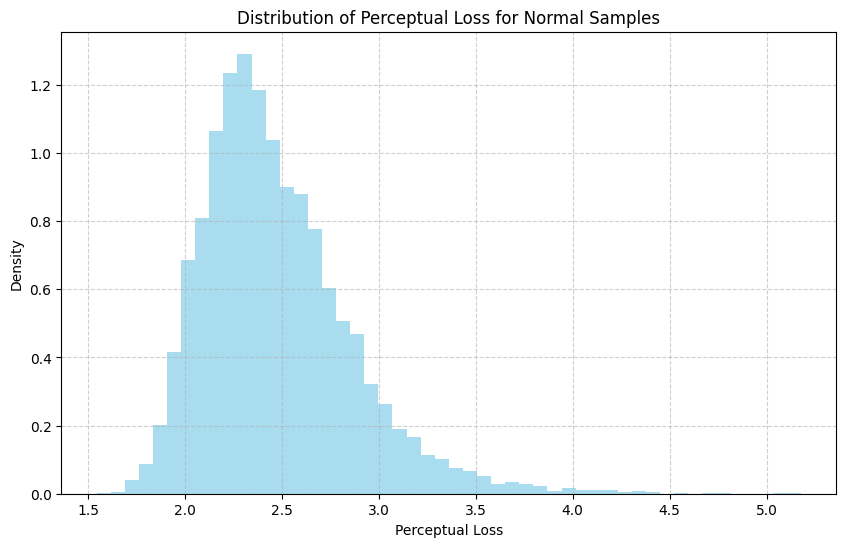

Mean Perceptual Loss: 2.4731
Median Perceptual Loss: 2.4057
Standard Deviation of Perceptual Loss: 0.3861


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'train_perceptual_losses' list is available from the previous cell execution

plt.figure(figsize=(10, 6))
plt.hist(train_perceptual_losses, bins=50, density=True, alpha=0.7, color='skyblue')
plt.title('Distribution of Perceptual Loss for Normal Samples')
plt.xlabel('Perceptual Loss')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# You can also print some statistics
print(f"Mean Perceptual Loss: {np.mean(train_perceptual_losses):.4f}")
print(f"Median Perceptual Loss: {np.median(train_perceptual_losses):.4f}")
print(f"Standard Deviation of Perceptual Loss: {np.std(train_perceptual_losses):.4f}")

In [ ]:
# Choose the 95th percentile as the OOD threshold
ood_threshold = np.percentile(train_perceptual_losses, 90)

# Print the calculated OOD threshold
print(f"Calculated OOD Threshold (90th Percentile of Normal Train Losses): {ood_threshold:.4f}")

Calculated OOD Threshold (90th Percentile of Normal Train Losses): 2.9628


### TEST dataloader - histogram

In [ ]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

# Ensure the model and criterion are in evaluation mode and on the correct device
model.eval()
model.to(device)
criterion.to(device) # Ensure criterion is also on the correct device

# Create a DataLoader for the filtered normal dataset (test set)
# Assuming normal_dataloader is already defined and contains the normal test samples
# If you intended to use the *test* split of the original MedMNIST data filtered for normal samples,
# you would need to create that dataloader here.
# For now, assuming 'normal_dataloader' refers to the filtered training data's dataloader as created earlier.
# If you need to filter the test set, please specify.

# Let's assume normal_dataloader is available and contains the normal samples you want to analyze.
# If you need to create a new dataloader for the test set with only normal samples,
# you would do something similar to cell 25e6a026 but with 'test_data'.
# For this task, we will use the existing 'normal_dataloader' which was created from the filtered training data.


print(f"Calculating perceptual loss for each sample in the normal dataloader...")

perceptual_losses = []

with torch.inference_mode(): # Use inference_mode for evaluation
    # for inputs, _ in tqdm(normal_test_dataloader, desc="Calculating Perceptual Loss"):
    for inputs, _ in tqdm(normal_corrupted_test_dataloaders_by_severity['severity_5'], desc="Calculating Perceptual Loss"):
        inputs = inputs.to(device)

        outputs = model(inputs)

        # Calculate perceptual loss for the batch
        # The criterion returns a tensor of shape (batch_size,) with the loss for each sample
        losses_per_sample = criterion(inputs, outputs)

        # Append the losses of the current batch to the list
        perceptual_losses.extend(losses_per_sample.cpu().numpy()) # Move to CPU and convert to numpy

# print("\nPerceptual loss for each sample:")
# for i, loss in enumerate(perceptual_losses):
    # print(f"Sample {i+1}: {loss:.4f}")

# Now you can analyze the 'perceptual_losses' list (e.g., plot a histogram, calculate statistics)
# to understand the distribution and identify a threshold.

Calculating perceptual loss for each sample in the normal dataloader...


Calculating Perceptual Loss: 100%|██████████| 2/2 [00:02<00:00,  1.05s/it]


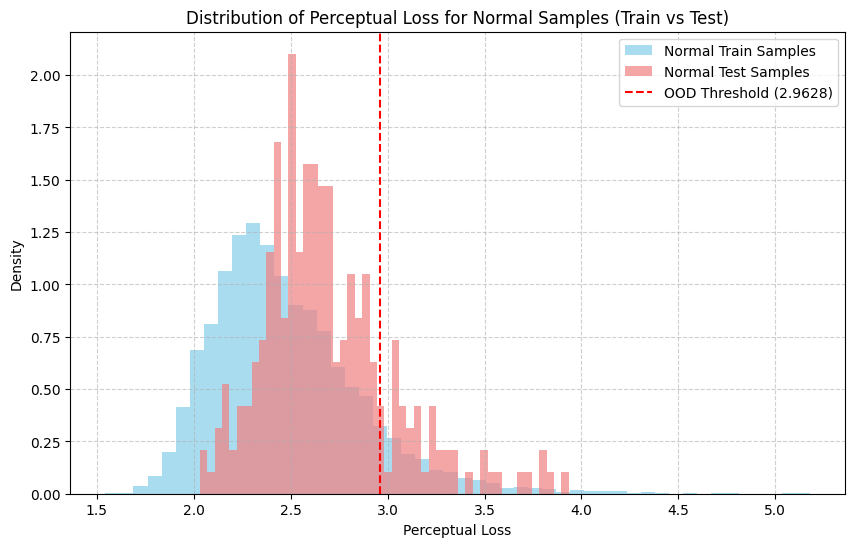

Train - Mean Perceptual Loss: 2.4731
Train - Median Perceptual Loss: 2.4057
Train - Standard Deviation of Perceptual Loss: 0.3861

Test - Mean Perceptual Loss: 2.6884
Test - Median Perceptual Loss: 2.6261
Test - Standard Deviation of Perceptual Loss: 0.3448


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'train_perceptual_losses' and 'perceptual_losses' lists are available from previous cell executions

plt.figure(figsize=(10, 6))

# Plot histogram for training losses
plt.hist(train_perceptual_losses, bins=50, density=True, alpha=0.7, color='skyblue', label='Normal Train Samples')

# Plot histogram for test losses (normal samples from test set)
plt.hist(perceptual_losses, bins=50, density=True, alpha=0.7, color='lightcoral', label='Normal Test Samples')

plt.axvline(x=ood_threshold, color='red', linestyle='--', label=f'OOD Threshold ({ood_threshold:.4f})')

plt.title('Distribution of Perceptual Loss for Normal Samples (Train vs Test)')
plt.xlabel('Perceptual Loss')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend() # Add a legend to distinguish between the two histograms
plt.show()

# You can also print some statistics for comparison
print(f"Train - Mean Perceptual Loss: {np.mean(train_perceptual_losses):.4f}")
print(f"Train - Median Perceptual Loss: {np.median(train_perceptual_losses):.4f}")
print(f"Train - Standard Deviation of Perceptual Loss: {np.std(train_perceptual_losses):.4f}")

print(f"\nTest - Mean Perceptual Loss: {np.mean(perceptual_losses):.4f}")
print(f"Test - Median Perceptual Loss: {np.median(perceptual_losses):.4f}")
print(f"Test - Standard Deviation of Perceptual Loss: {np.std(perceptual_losses):.4f}")

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Assuming 'perceptual_losses' list is available from the previous cell execution

# plt.figure(figsize=(10, 6))
# plt.hist(perceptual_losses, bins=50, density=True, alpha=0.7, color='skyblue')
# plt.title('Distribution of Perceptual Loss for Normal Samples')
# plt.xlabel('Perceptual Loss')
# plt.ylabel('Density')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.show()

# # You can also print some statistics
# print(f"Mean Perceptual Loss: {np.mean(perceptual_losses):.4f}")
# print(f"Median Perceptual Loss: {np.median(perceptual_losses):.4f}")
# print(f"Standard Deviation of Perceptual Loss: {np.std(perceptual_losses):.4f}")

### TRAIN dataloader MALIGNANT - histogram

In [ ]:
############################################################
# NORMAL TEST DATA LOADER WITH 'NORMAL' CLASS ONLY
############################################################

from torch.utils.data import Subset

# Assuming train_data is your original dataset loaded from medmnist
# and you want to filter the training data

# Get the indices of samples belonging to the 'malignant' class (label 1)
malignant_indices = [i for i, (_, label) in enumerate(train_data) if label == 0]

# Create a Subset of the original dataset using these indices
malignant_dataset = Subset(train_data, malignant_indices)

# Create a new DataLoader for the filtered dataset
BATCH_SIZE = 128 # Use your desired batch size
malignant_dataloader = DataLoader(dataset=malignant_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Original dataset size: {len(train_data)}")
print(f"Filtered 'malignant' dataset size: {len(malignant_dataset)}")
print(f"Filtered 'malignant' dataloader has {len(malignant_dataloader)} batches.")

Original dataset size: 546
Filtered 'malignant' dataset size: 147
Filtered 'malignant' dataloader has 2 batches.


In [ ]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

# Ensure the model and criterion are in evaluation mode and on the correct device
model.eval()
model.to(device)
criterion.to(device) # Ensure criterion is also on the correct device

# Create a DataLoader for the filtered normal dataset (test set)
# Assuming normal_dataloader is already defined and contains the normal test samples
# If you intended to use the *test* split of the original MedMNIST data filtered for normal samples,
# you would need to create that dataloader here.
# For now, assuming 'normal_dataloader' refers to the filtered training data's dataloader as created earlier.
# If you need to filter the test set, please specify.

# Let's assume normal_dataloader is available and contains the normal samples you want to analyze.
# If you need to create a new dataloader for the test set with only normal samples,
# you would do something similar to cell 25e6a026 but with 'test_data'.
# For this task, we will use the existing 'normal_dataloader' which was created from the filtered training data.


print(f"Calculating perceptual loss for each sample in the normal dataloader...")

malignant_perceptual_losses = []

with torch.inference_mode(): # Use inference_mode for evaluation
    for inputs, _ in tqdm(malignant_dataloader, desc="Calculating Perceptual Loss"):
        inputs = inputs.to(device)

        outputs = model(inputs)

        # Calculate perceptual loss for the batch
        # The criterion returns a tensor of shape (batch_size,) with the loss for each sample
        losses_per_sample = criterion(inputs, outputs)

        # Append the losses of the current batch to the list
        malignant_perceptual_losses.extend(losses_per_sample.cpu().numpy()) # Move to CPU and convert to numpy

print("\nPerceptual loss for each sample:")
for i, loss in enumerate(malignant_perceptual_losses):
    print(f"Sample {i+1}: {loss:.4f}")

# Now you can analyze the 'perceptual_losses' list (e.g., plot a histogram, calculate statistics)
# to understand the distribution and identify a threshold.

Calculating perceptual loss for each sample in the normal dataloader...


Calculating Perceptual Loss: 100%|██████████| 2/2 [00:01<00:00,  1.62it/s]


Perceptual loss for each sample:
Sample 1: 4.3939
Sample 2: 4.6468
Sample 3: 10.4407
Sample 4: 8.4175
Sample 5: 5.7937
Sample 6: 8.6160
Sample 7: 6.0596
Sample 8: 6.2739
Sample 9: 7.2014
Sample 10: 12.7330
Sample 11: 5.7533
Sample 12: 5.2085
Sample 13: 7.4655
Sample 14: 7.0878
Sample 15: 7.1907
Sample 16: 5.4480
Sample 17: 13.1625
Sample 18: 6.2241
Sample 19: 7.8375
Sample 20: 6.1096
Sample 21: 7.4252
Sample 22: 6.9487
Sample 23: 5.4682
Sample 24: 5.5576
Sample 25: 4.9961
Sample 26: 5.3991
Sample 27: 5.9401
Sample 28: 6.7570
Sample 29: 8.0859
Sample 30: 5.4668
Sample 31: 4.4065
Sample 32: 8.2417
Sample 33: 5.5516
Sample 34: 6.6136
Sample 35: 9.6887
Sample 36: 5.5063
Sample 37: 6.4772
Sample 38: 6.5439
Sample 39: 6.2541
Sample 40: 5.4692
Sample 41: 8.6238
Sample 42: 8.5184
Sample 43: 6.3616
Sample 44: 9.4299
Sample 45: 5.3990
Sample 46: 5.0769
Sample 47: 7.8359
Sample 48: 13.8318
Sample 49: 6.6958
Sample 50: 4.8234
Sample 51: 6.2683
Sample 52: 8.2864
Sample 53: 5.5770
Sample 54: 7.1461

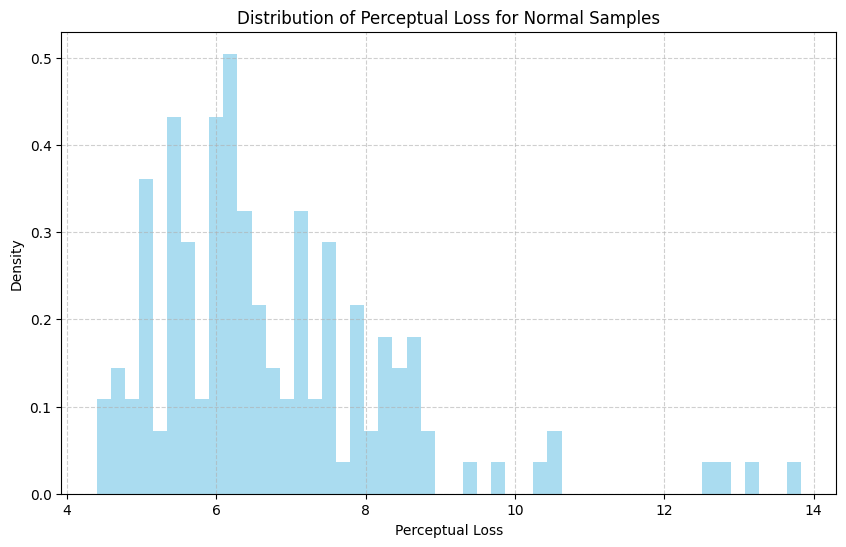

Mean Perceptual Loss: 6.7658
Median Perceptual Loss: 6.3278
Standard Deviation of Perceptual Loss: 1.6676


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'malignant_perceptual_losses' list is available from the previous cell execution

plt.figure(figsize=(10, 6))
plt.hist(malignant_perceptual_losses, bins=50, density=True, alpha=0.7, color='skyblue')
plt.title('Distribution of Perceptual Loss for Normal Samples')
plt.xlabel('Perceptual Loss')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# You can also print some statistics
print(f"Mean Perceptual Loss: {np.mean(malignant_perceptual_losses):.4f}")
print(f"Median Perceptual Loss: {np.median(malignant_perceptual_losses):.4f}")
print(f"Standard Deviation of Perceptual Loss: {np.std(malignant_perceptual_losses):.4f}")

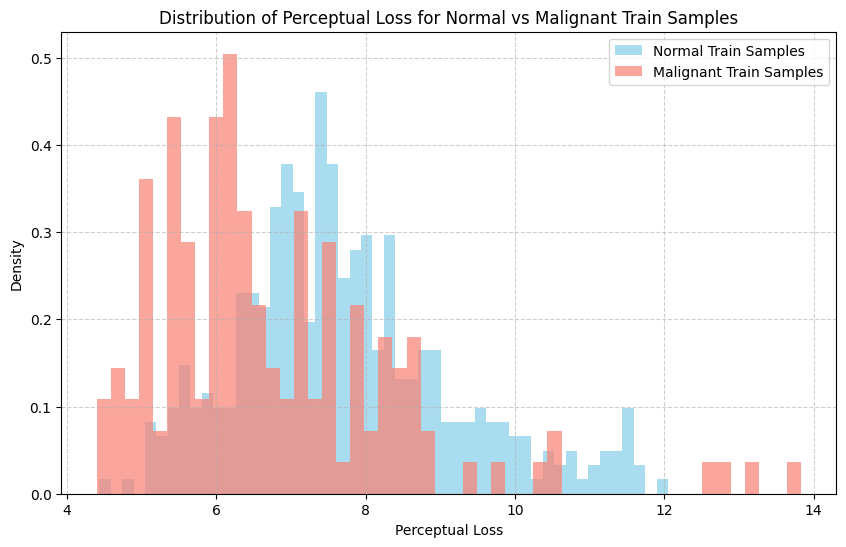

Normal Train - Mean Perceptual Loss: 7.7152
Normal Train - Median Perceptual Loss: 7.5017
Normal Train - Standard Deviation of Perceptual Loss: 1.4487

Malignant Train - Mean Perceptual Loss: 6.7658
Malignant Train - Median Perceptual Loss: 6.3278
Malignant Train - Standard Deviation of Perceptual Loss: 1.6676


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'train_perceptual_losses' and 'malignant_perceptual_losses' lists are available from previous cell executions

plt.figure(figsize=(10, 6))

# Plot histogram for normal training losses
plt.hist(train_perceptual_losses, bins=50, density=True, alpha=0.7, color='skyblue', label='Normal Train Samples')

# Plot histogram for malignant training losses
plt.hist(malignant_perceptual_losses, bins=50, density=True, alpha=0.7, color='salmon', label='Malignant Train Samples')

plt.title('Distribution of Perceptual Loss for Normal vs Malignant Train Samples')
plt.xlabel('Perceptual Loss')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend() # Add a legend to distinguish between the two histograms
plt.show()

# You can also print some statistics for comparison
print(f"Normal Train - Mean Perceptual Loss: {np.mean(train_perceptual_losses):.4f}")
print(f"Normal Train - Median Perceptual Loss: {np.median(train_perceptual_losses):.4f}")
print(f"Normal Train - Standard Deviation of Perceptual Loss: {np.std(train_perceptual_losses):.4f}")

print(f"\nMalignant Train - Mean Perceptual Loss: {np.mean(malignant_perceptual_losses):.4f}")
print(f"Malignant Train - Median Perceptual Loss: {np.median(malignant_perceptual_losses):.4f}")
print(f"Malignant Train - Standard Deviation of Perceptual Loss: {np.std(malignant_perceptual_losses):.4f}")

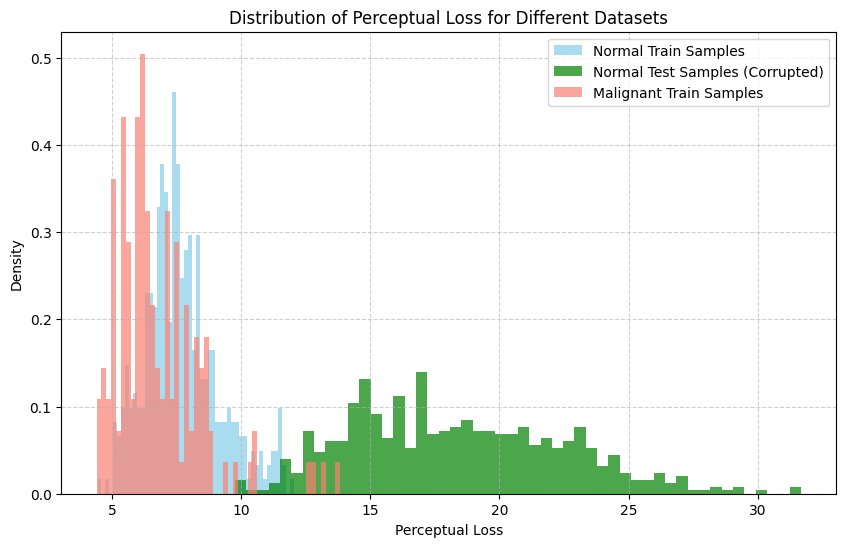

Normal Train - Mean Perceptual Loss: 7.7152
Normal Train - Median Perceptual Loss: 7.5017
Normal Train - Standard Deviation of Perceptual Loss: 1.4487

Normal Test (Corrupted) - Mean Perceptual Loss: 18.3323
Normal Test (Corrupted) - Median Perceptual Loss: 17.7971
Normal Test (Corrupted) - Standard Deviation of Perceptual Loss: 4.1113

Malignant Train - Mean Perceptual Loss: 6.7658
Malignant Train - Median Perceptual Loss: 6.3278
Malignant Train - Standard Deviation of Perceptual Loss: 1.6676


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'train_perceptual_losses', 'perceptual_losses' (normal test),
# and 'malignant_perceptual_losses' lists are available from previous cell executions

plt.figure(figsize=(10, 6))

# Plot histogram for normal training losses
plt.hist(train_perceptual_losses, bins=50, density=True, alpha=0.7, color='skyblue', label='Normal Train Samples')

# Plot histogram for normal test losses (normal samples from corrupted test set)
plt.hist(perceptual_losses, bins=50, density=True, alpha=0.7, color='green', label='Normal Test Samples (Corrupted)')

# Plot histogram for malignant training losses
plt.hist(malignant_perceptual_losses, bins=50, density=True, alpha=0.7, color='salmon', label='Malignant Train Samples')


plt.title('Distribution of Perceptual Loss for Different Datasets')
plt.xlabel('Perceptual Loss')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend() # Add a legend to distinguish between the histograms
plt.show()

# You can also print some statistics for comparison
print(f"Normal Train - Mean Perceptual Loss: {np.mean(train_perceptual_losses):.4f}")
print(f"Normal Train - Median Perceptual Loss: {np.median(train_perceptual_losses):.4f}")
print(f"Normal Train - Standard Deviation of Perceptual Loss: {np.std(train_perceptual_losses):.4f}")

print(f"\nNormal Test (Corrupted) - Mean Perceptual Loss: {np.mean(perceptual_losses):.4f}")
print(f"Normal Test (Corrupted) - Median Perceptual Loss: {np.median(perceptual_losses):.4f}")
print(f"Normal Test (Corrupted) - Standard Deviation of Perceptual Loss: {np.std(perceptual_losses):.4f}")

print(f"\nMalignant Train - Mean Perceptual Loss: {np.mean(malignant_perceptual_losses):.4f}")
print(f"Malignant Train - Median Perceptual Loss: {np.median(malignant_perceptual_losses):.4f}")
print(f"Malignant Train - Standard Deviation of Perceptual Loss: {np.std(malignant_perceptual_losses):.4f}")

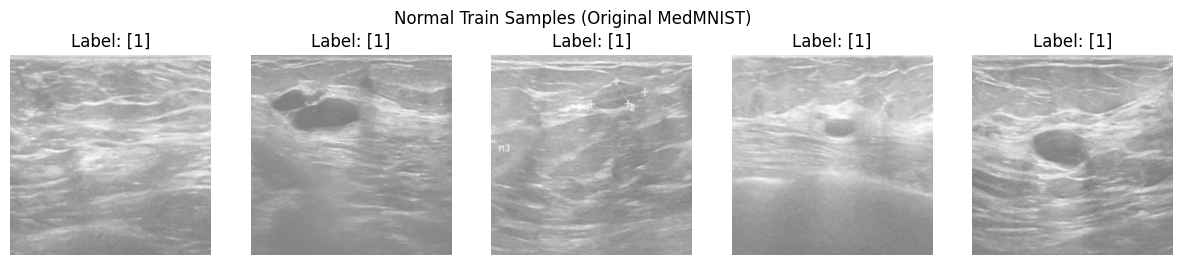

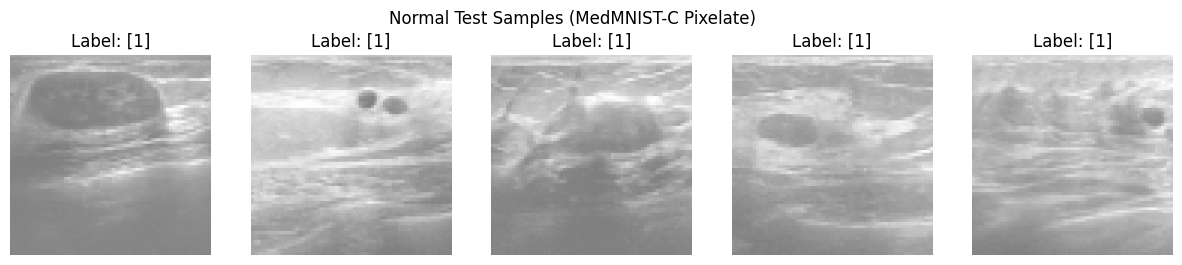

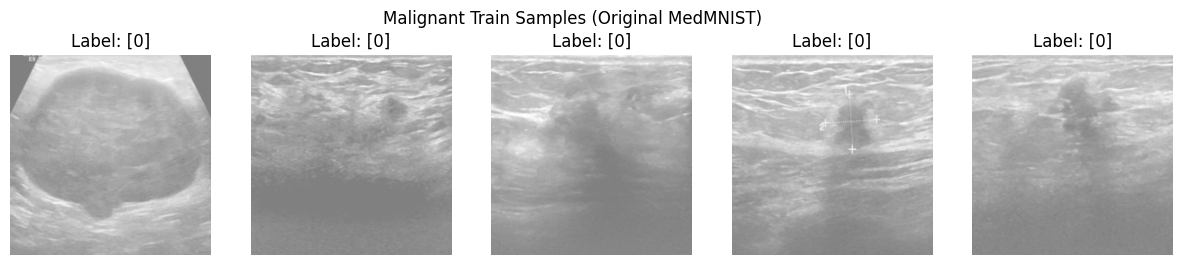

In [ ]:
import matplotlib.pyplot as plt
import torchvision

# Function to show multiple samples from a dataset
def show_samples(dataset, title, num_samples=5):
    plt.figure(figsize=(15, 3))
    plt.suptitle(title)
    for i in range(min(num_samples, len(dataset))):
        # Get one sample from the dataset
        # Since it's a Subset, indexing accesses the element within the subset
        image, label = dataset[i]

        # Ensure the image is a PyTorch Tensor with shape (C, H, W)
        if not isinstance(image, torch.Tensor):
            # If it's a PIL Image, convert to Tensor (already done by initial transform)
            # If it's a NumPy array, convert to Tensor
            image = torch.from_numpy(image)
            if image.ndim == 2:
                 image = image.unsqueeze(0) # Add channel dimension if grayscale

        # For visualization, we need to reverse the normalization and potentially permute dimensions
        # Assuming the images are 3 channels as_rgb=True and normalized with mean=0.5, std=0.5
        # Reverse normalization: image = image * std + mean
        mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1) # Reshape for broadcasting
        std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
        display_image = image * std + mean

        # Clamp values to be in [0, 1] in case of floating point inaccuracies
        display_image = torch.clamp(display_image, 0, 1)

        # Permute dimensions from (C, H, W) to (H, W, C) for matplotlib
        display_image = display_image.permute(1, 2, 0)

        # Convert to numpy array
        display_image = display_image.numpy()

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(display_image)
        plt.title(f"Label: {label}")
        plt.axis('off')

    plt.show()

# Display samples from each dataset
show_samples(normal_train_dataset, "Normal Train Samples (Original MedMNIST)")
show_samples(normal_test_dataset, "Normal Test Samples (MedMNIST-C Pixelate)")
show_samples(malignant_dataset, "Malignant Train Samples (Original MedMNIST)")

## other metrics

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
from torchmetrics import MeanSquaredError, StructuralSimilarityIndexMeasure
import torchvision.transforms as transforms
import torch.nn.functional as F # Import F for F.mse_loss


# Ensure the model is in evaluation mode and on the correct device
model.eval()
model.to(device)

# Data preparation (assuming train_data and normal_dataset are available from previous cells)
# You might want to evaluate on a separate validation or test set,
# but for demonstration, we'll use the filtered normal_dataset

# Define a transform for evaluation data (matching the training transform but without augmentation)
# Using the transform defined earlier which includes Resize, ToTensor, and contrast_stretching
eval_transform = transforms.Compose([
    transforms.Resize((64, 64)), # Resize to match autoencoder input
    transforms.ToTensor(),
    transforms.Lambda(contrast_stretching), # Use the same contrast stretching
])

# Create a DataLoader for the dataset you want to evaluate on
# For example, evaluating on the filtered normal dataset:
eval_dataset = normal_train_dataset # Or use val_data or test_data if prepared appropriately
eval_dataloader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False) # Use a larger batch size for evaluation if memory allows

# Initialize metrics
mse = MeanSquaredError().to(device)
# SSIM requires 3 channels and specific data ranges, adjust if needed for grayscale
# For grayscale (1 channel), you might need a specific SSIM implementation or repeat the channel
# Here, we'll stick with MSE for simplicity with grayscale
# ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(device) # Assuming image values are in [0, 1] after transform and model sigmoid


print(f"Evaluating model on dataset with {len(eval_dataset)} samples...")

total_mse = 0.0
# total_ssim = 0.0 # For SSIM

with torch.inference_mode(): # Use inference_mode for evaluation
    for inputs, _ in tqdm(eval_dataloader, desc="Evaluating"):
        inputs = inputs.to(device)

        # Forward pass
        outputs = model(inputs)

        # Calculate metrics
        # Ensure inputs and outputs are on the same device as metrics
        # Explicitly move inputs and outputs to the device of the metric
        mse.update(outputs.to(mse.device), inputs.to(mse.device))
        # SSIM needs to handle the channel dimension - if inputs/outputs are 1 channel, adjust
        # If using the repeat trick for VGG, inputs/outputs to SSIM should be 1 channel still
        # total_ssim += ssim(outputs, inputs).item() * inputs.size(0) # Weight by batch size

        # You can also calculate batch-wise metrics manually
        # batch_mse = F.mse_loss(outputs, inputs, reduction='sum') # Use sum to get per-batch total loss
        # total_mse += batch_mse.item()

# Get final metric values
average_mse = mse.compute()
# average_ssim = total_ssim / len(eval_dataset) # For SSIM

print(f"\nEvaluation Complete.")
print(f"Average Mean Squared Error: {average_mse.item():.4f}")
# print(f"Average SSIM: {average_ssim:.4f}") # For SSIM

# Reset metrics for future use
mse.reset()
# ssim.reset() # For SSIM

Evaluating model on dataset with 399 samples...


Evaluating: 100%|██████████| 4/4 [00:00<00:00,  4.66it/s]


Evaluation Complete.
Average Mean Squared Error: 0.3758


## Define corruption types


In [ ]:
corrupted_losses = {} # This initialization was in the previous step's thinking, not code. It should be before the loop.

for corruption in ["speckle_noise", "motion_blur", "brightness_up", "brightness_down", "pixelate", "contrast_down"]:
    print(f"Processing corruption type: {corruption}")

    # Load the corrupted dataset for the current corruption
    corrupted_test_dataset = CorruptedMedMNIST(
        dataset_name=config['dataset'],
        corruption=corruption,
        root=config['medmnistc_path'],
        mmap_mode='r',
        norm_mean=mean,
        norm_std=std
    )

    # Filter the corrupted dataset to include only 'normal' samples (label 1)
    normal_corrupted_test_indices = [i for i, (_, label) in enumerate(corrupted_test_dataset) if label == 1]
    normal_corrupted_test_dataset = Subset(corrupted_test_dataset, normal_corrupted_test_indices)

    # Create a DataLoader for the filtered normal corrupted dataset
    normal_corrupted_test_dataloader = DataLoader(dataset=normal_corrupted_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Calculate perceptual loss for each sample in the filtered normal corrupted dataloader
    print(f"Calculating perceptual loss for normal samples in {corruption} corrupted data...")

    current_corruption_losses = []

    with torch.inference_mode():
        for inputs, _ in tqdm(normal_corrupted_test_dataloader, desc=f"Perceptual Loss ({corruption})"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            losses_per_sample = criterion(inputs, outputs)
            current_corruption_losses.extend(losses_per_sample.cpu().numpy())

    # Store the calculated losses in the dictionary
    corrupted_losses[corruption] = current_corruption_losses

    print(f"Finished processing {corruption}.")

Processing corruption type: speckle_noise
Calculating perceptual loss for normal samples in speckle_noise corrupted data...


Perceptual Loss (speckle_noise): 100%|██████████| 5/5 [00:04<00:00,  1.08it/s]


Finished processing speckle_noise.
Processing corruption type: motion_blur
Calculating perceptual loss for normal samples in motion_blur corrupted data...


Perceptual Loss (motion_blur): 100%|██████████| 5/5 [00:04<00:00,  1.08it/s]


Finished processing motion_blur.
Processing corruption type: brightness_up
Calculating perceptual loss for normal samples in brightness_up corrupted data...


...

Finished processing brightness_down.
Processing corruption type: pixelate
Calculating perceptual loss for normal samples in pixelate corrupted data...


Perceptual Loss (pixelate): 100%|██████████| 5/5 [00:04<00:00,  1.06it/s]


Finished processing pixelate.
Processing corruption type: contrast_down
Calculating perceptual loss for normal samples in contrast_down corrupted data...


Perceptual Loss (contrast_down): 100%|██████████| 5/5 [00:04<00:00,  1.07it/s]

Finished processing contrast_down.


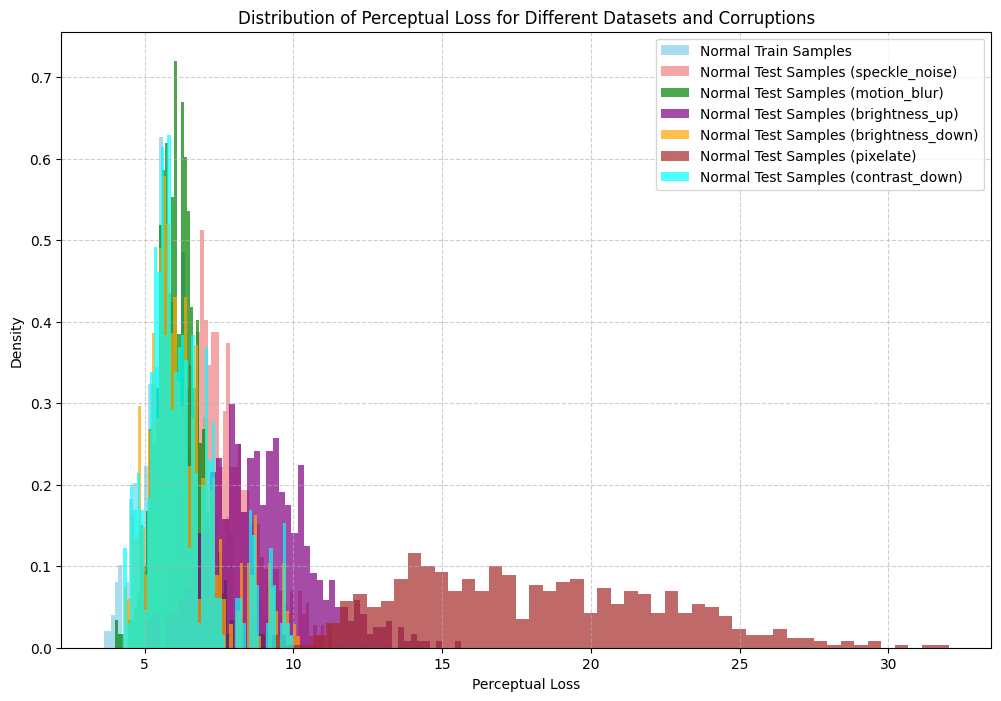

Normal Train - Mean Perceptual Loss: 6.1689
Normal Train - Median Perceptual Loss: 5.9688
Normal Train - Standard Deviation of Perceptual Loss: 1.1914

Perceptual Loss Statistics for Normal Samples in Corrupted Test Datasets:
  speckle_noise:
    Mean: 7.4834
    Median: 7.3151
    Standard Deviation: 1.1837
  motion_blur:
    Mean: 6.1135
    Median: 6.0697
    Standard Deviation: 0.7103
  brightness_up:
    Mean: 8.9433
    Median: 8.7858
    Standard Deviation: 1.7540
  brightness_down:
    Mean: 6.3316
    Median: 6.0465
    Standard Deviation: 1.2222
  pixelate:
    Mean: 18.0581
    Median: 17.4551
    Standard Deviation: 4.3300
  contrast_down:
    Mean: 6.2814
    Median: 5.9995
    Standard Deviation: 1.2189


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'train_perceptual_losses' and 'corrupted_losses' dictionary are available from previous cell executions

plt.figure(figsize=(12, 8))

# Plot histogram for normal training losses
plt.hist(train_perceptual_losses, bins=50, density=True, alpha=0.7, color='skyblue', label='Normal Train Samples')

# Plot histograms for normal samples from each corrupted test dataset
colors = ['lightcoral', 'green', 'purple', 'orange', 'brown', 'cyan']
for i, (corruption, losses) in enumerate(corrupted_losses.items()):
    plt.hist(losses, bins=50, density=True, alpha=0.7, color=colors[i % len(colors)], label=f'Normal Test Samples ({corruption})')

plt.title('Distribution of Perceptual Loss for Different Datasets and Corruptions')
plt.xlabel('Perceptual Loss')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Print statistics for comparison
print(f"Normal Train - Mean Perceptual Loss: {np.mean(train_perceptual_losses):.4f}")
print(f"Normal Train - Median Perceptual Loss: {np.median(train_perceptual_losses):.4f}")
print(f"Normal Train - Standard Deviation of Perceptual Loss: {np.std(train_perceptual_losses):.4f}")

print("\nPerceptual Loss Statistics for Normal Samples in Corrupted Test Datasets:")
for corruption, losses in corrupted_losses.items():
    print(f"  {corruption}:")
    print(f"    Mean: {np.mean(losses):.4f}")
    print(f"    Median: {np.median(losses):.4f}")
    print(f"    Standard Deviation: {np.std(losses):.4f}")

In [ ]:
# 1. Load the original BreastMNIST training dataset
train_data = BreastMNIST(
    split='train',
    transform=data_transform,
    download=True,
    root=config['medmnist_path'],
    as_rgb=True,
    size=224,
)

# 2. Filter for 'normal, benign' class (label 1)
normal_train_indices = [i for i, (_, label) in enumerate(train_data) if label == 1]
normal_train_dataset = Subset(train_data, normal_train_indices)

# 3. Create a DataLoader for the normal training dataset
BATCH_SIZE = 128
normal_train_dataloader = DataLoader(dataset=normal_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Original train dataset size: {len(train_data)}")
print(f"Filtered 'normal' train dataset size: {len(normal_train_dataset)}")
print(f"Filtered 'normal' train dataloader has {len(normal_train_dataloader)} batches.")

Original train dataset size: 546
Filtered 'normal' train dataset size: 399
Filtered 'normal' train dataloader has 4 batches.


In [ ]:
# 4. Define a list of corruption types
corruption_types = ["speckle_noise", "motion_blur", "brightness_up", "brightness_down", "pixelate", "contrast_down"]

# 5. Initialize an empty dictionary to store the loaded corrupted datasets
corrupted_test_datasets = {}

# 7. Initialize an empty dictionary to store the DataLoaders for filtered normal samples
normal_corrupted_test_dataloaders = {}

print(f"Defined corruption types: {corruption_types}")

Defined corruption types: ['speckle_noise', 'motion_blur', 'brightness_up', 'brightness_down', 'pixelate', 'contrast_down']


In [ ]:
# 6. Iterate through the list of corruption types and load each corrupted dataset
for corruption in corruption_types:
    print(f"Loading corrupted dataset for: {corruption}")
    corrupted_test_dataset = CorruptedMedMNIST(
        dataset_name=config['dataset'],
        corruption=corruption,
        root=config['medmnistc_path'],
        mmap_mode='r',
        norm_mean=mean,
        norm_std=std
    )
    corrupted_test_datasets[corruption] = corrupted_test_dataset

    # 8. Filter the corrupted dataset and create a DataLoader for normal samples
    print(f"Filtering '{corruption}' dataset for normal samples and creating DataLoader...")
    normal_corrupted_test_indices = [i for i, (_, label) in enumerate(corrupted_test_dataset) if label == 1]
    normal_corrupted_test_dataset = Subset(corrupted_test_dataset, normal_corrupted_test_indices)

    # Use the same batch size as the training dataloader
    normal_corrupted_test_dataloader = DataLoader(dataset=normal_corrupted_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    normal_corrupted_test_dataloaders[corruption] = normal_corrupted_test_dataloader

    print(f"Filtered '{corruption}' dataset size: {len(normal_corrupted_test_dataset)}")
    print(f"Filtered '{corruption}' dataloader has {len(normal_corrupted_test_dataloader)} batches.")

print("\nFinished loading and preparing all corrupted datasets and dataloaders.")

Loading corrupted dataset for: speckle_noise
Filtering 'speckle_noise' dataset for normal samples and creating DataLoader...
Filtered 'speckle_noise' dataset size: 570
Filtered 'speckle_noise' dataloader has 5 batches.
Loading corrupted dataset for: motion_blur
Filtering 'motion_blur' dataset for normal samples and creating DataLoader...
Filtered 'motion_blur' dataset size: 570
Filtered 'motion_blur' dataloader has 5 batches.
Loading corrupted dataset for: brightness_up
Filtering 'brightness_up' dataset for normal samples and creating DataLoader...
Filtered 'brightness_up' dataset size: 570
Filtered 'brightness_up' dataloader has 5 batches.
Loading corrupted dataset for: brightness_down
Filtering 'brightness_down' dataset for normal samples and creating DataLoader...
Filtered 'brightness_down' dataset size: 570
Filtered 'brightness_down' dataloader has 5 batches.
Loading corrupted dataset for: pixelate
Filtering 'pixelate' dataset for normal samples and creating DataLoader...
Filtered 

In [ ]:
# Based on the available information and the structure of the CorruptedMedMNIST class in the notebook,
# it appears that the CorruptedMedMNIST class is initialized with a specific 'corruption' name (e.g., "pixelate").
# The __init__ method loads a single .npz file based on the dataset_name and corruption name,
# which is expected to contain the test_images and test_labels for that specific corruption type.
# There is no explicit parameter in the __init__ method or the file loading logic
# that allows specifying a 'severity' level (e.g., severity=1, severity=2, etc.).

# To confirm this, we would typically consult the official documentation or source code of the medmnistc library.
# However, based on the provided notebook code and the structure of the CorruptedMedMNIST class,
# it seems each .npz file corresponds to a single corruption type, likely at a predefined severity level.

# Therefore, based on the current implementation and the available code,
# the CorruptedMedMNIST class does not directly support loading data with varying severity levels
# via an explicit 'severity' parameter.

# If different severity levels exist for these corruptions in the MedMNIST-C dataset release,
# they are likely stored in separate .npz files with names that might indicate the severity level
# (e.g., "pixelate_severity1.npz", "pixelate_severity2.npz"), or the severity level is implicit
# in the single provided corrupted file per type.

# Since the current CorruptedMedMNIST class only takes the corruption name and expects a file
# named "{corruption}.npz", it is designed to load a single version of each corruption.
# This implies that for the corruption types used ("speckle_noise", "motion_blur", "brightness_up",
# "brightness_down", "pixelate", "contrast_down"), we are currently only evaluating one specific,
# likely the highest or a standard, severity level provided in the downloaded .npz files.

# If evaluating different severity levels is crucial and these levels are available in separate files,
# we would need to modify the CorruptedMedMNIST class or the data loading loop to iterate through
# different filenames corresponding to different severities for each corruption type.

# For the scope of this subtask, we have determined *how* severity is handled (or not explicitly handled)
# by the provided CorruptedMedMNIST class. It does not support specifying severity levels directly.
# Thus, we are currently evaluating a single severity level for each corruption type included in
# the downloaded .npz files.

# As per the instructions, if severity levels are not directly supported, we note this limitation.
# We are currently evaluating only one severity level per corruption type based on the available data loading class.

print("Based on the provided CorruptedMedMNIST class implementation, severity levels cannot be specified directly when loading corrupted datasets.")
print("Each loaded corrupted dataset likely corresponds to a single, predefined severity level.")
print("Therefore, for this evaluation, we are working with one severity level per corruption type as provided in the .npz files.")

# The specific severity levels being evaluated are implicit in the downloaded .npz files
# for each corruption type used in the previous steps.
# We are not able to determine or select different severity levels with the current class.

# Note: To evaluate different severity levels, the data loading mechanism would need to be
# updated to handle filenames or parameters corresponding to different severity levels,
# assuming such data is available.

Based on the provided CorruptedMedMNIST class implementation, severity levels cannot be specified directly when loading corrupted datasets.
Each loaded corrupted dataset likely corresponds to a single, predefined severity level.
Therefore, for this evaluation, we are working with one severity level per corruption type as provided in the .npz files.


In [ ]:
import numpy as np

# Calculate and print descriptive statistics for normal training losses
print("Normal Train Samples (ID) - Perceptual Loss Statistics:")
print(f"  Mean: {np.mean(train_perceptual_losses):.4f}")
print(f"  Median: {np.median(train_perceptual_losses):.4f}")
print(f"  Standard Deviation: {np.std(train_perceptual_losses):.4f}")

print("\nPerceptual Loss Statistics for Normal Samples in Corrupted Test Datasets (OOD):")
# Calculate and print descriptive statistics for losses from each corrupted dataset
for corruption, losses in corrupted_losses.items():
    print(f"  {corruption}:")
    print(f"    Mean: {np.mean(losses):.4f}")
    print(f"    Median: {np.median(losses):.4f}")
    print(f"    Standard Deviation: {np.std(losses):.4f}")

# Note: The comparison and analysis of the statistics is done by observing the printed output.
# We are looking for shifts in mean, median, and standard deviation between the ID data
# and the OOD data for each corruption type.

Normal Train Samples (ID) - Perceptual Loss Statistics:
  Mean: 6.1689
  Median: 5.9688
  Standard Deviation: 1.1914

Perceptual Loss Statistics for Normal Samples in Corrupted Test Datasets (OOD):
  speckle_noise:
    Mean: 7.4834
    Median: 7.3151
    Standard Deviation: 1.1837
  motion_blur:
    Mean: 6.1135
    Median: 6.0697
    Standard Deviation: 0.7103
  brightness_up:
    Mean: 8.9433
    Median: 8.7858
    Standard Deviation: 1.7540
  brightness_down:
    Mean: 6.3316
    Median: 6.0465
    Standard Deviation: 1.2222
  pixelate:
    Mean: 18.0581
    Median: 17.4551
    Standard Deviation: 4.3300
  contrast_down:
    Mean: 6.2814
    Median: 5.9995
    Standard Deviation: 1.2189


In [ ]:
# Choose the 95th percentile as the OOD threshold
ood_threshold = np.percentile(train_perceptual_losses, 95)

# Print the calculated OOD threshold
print(f"Calculated OOD Threshold (95th Percentile of Normal Train Losses): {ood_threshold:.4f}")

Calculated OOD Threshold (95th Percentile of Normal Train Losses): 8.7681


Evaluation on Normal Train Samples (ID data):
  Number of samples: 399
  False Positives (ID samples flagged as OOD): 20
  True Negatives (ID samples flagged as ID): 379
------------------------------
Evaluation on Normal Test Samples (speckle_noise corruption) (OOD data):
  Number of samples: 570
  True Positives (OOD samples flagged as OOD): 82
  False Negatives (OOD samples flagged as ID): 488
  Percentage of OOD samples detected: 14.39%
------------------------------
Evaluation on Normal Test Samples (motion_blur corruption) (OOD data):
  Number of samples: 570
  True Positives (OOD samples flagged as OOD): 3
  False Negatives (OOD samples flagged as ID): 567
  Percentage of OOD samples detected: 0.53%
------------------------------
Evaluation on Normal Test Samples (brightness_up corruption) (OOD data):
  Number of samples: 570
  True Positives (OOD samples flagged as OOD): 287
  False Negatives (OOD samples flagged as ID): 283
  Percentage of OOD samples detected: 50.35%
--------

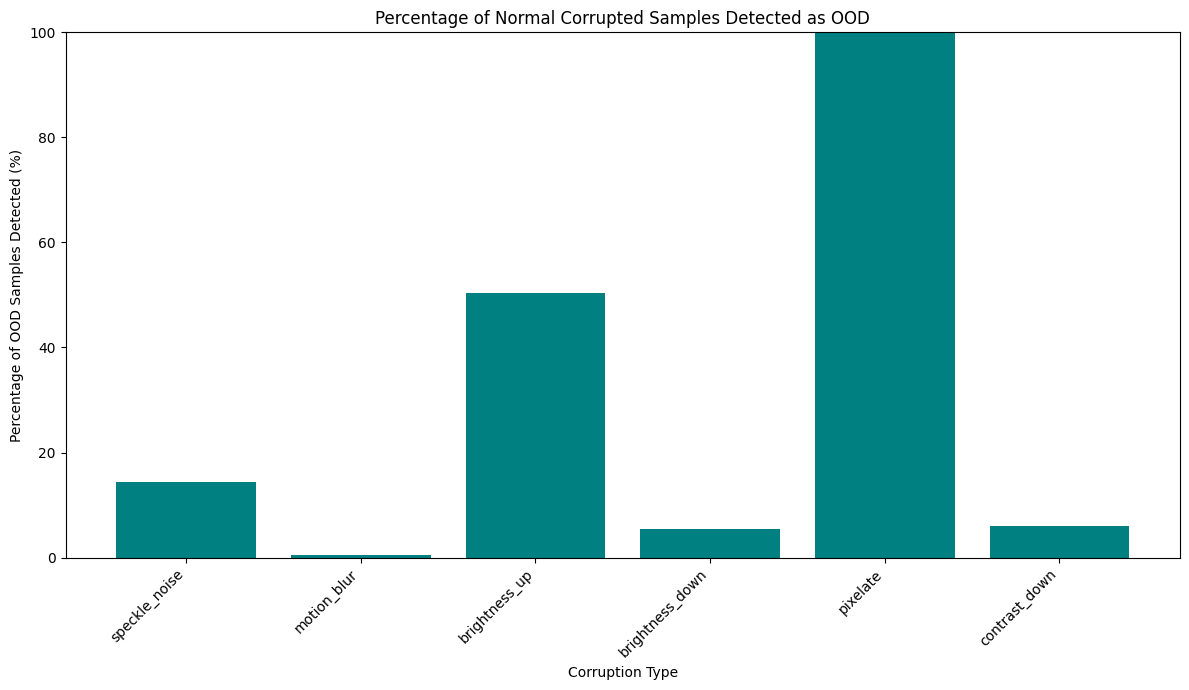

In [ ]:
# Assuming 'train_perceptual_losses' and 'corrupted_losses' are available
# Assuming 'ood_threshold' is available

metrics_results = {}
ood_detection_percentages = {}

# Evaluate on ID data (Normal Train Samples)
id_losses = np.array(train_perceptual_losses)
# For ID data, actual label is "in-distribution" (or Normal, which we treat as ID)
# Predicted label is "OOD" if loss > threshold, "ID" if loss <= threshold
id_predictions_ood = id_losses > ood_threshold

# TP for ID data: should be 0 (no ID samples are truly OOD)
# FP for ID data: ID samples incorrectly flagged as OOD (loss > threshold)
# TN for ID data: ID samples correctly flagged as ID (loss <= threshold)
# FN for ID data: should be 0 (no ID samples are truly OOD)

# In the context of OOD detection, we are primarily interested in how many ID samples
# are *incorrectly* flagged as OOD (False Positives) and how many OOD samples
# are *correctly* flagged as OOD (True Positives).
# The standard TP/FP/TN/FN definitions are usually for binary classification where
# one class is positive and the other is negative. Here, we have ID vs OOD.
# Let's redefine TP/FP/TN/FN based on OOD being the 'positive' class.

# For ID data (truth = ID, which is 'negative' for OOD detection):
# FP_id = number of ID samples with loss > threshold (incorrectly flagged as OOD)
# TN_id = number of ID samples with loss <= threshold (correctly flagged as ID)
FP_id = np.sum(id_predictions_ood)
TN_id = len(id_losses) - FP_id

# We don't have true TP or FN from the ID data perspective for OOD detection,
# as the ground truth for all ID samples is "not OOD".

print("Evaluation on Normal Train Samples (ID data):")
print(f"  Number of samples: {len(id_losses)}")
print(f"  False Positives (ID samples flagged as OOD): {FP_id}")
print(f"  True Negatives (ID samples flagged as ID): {TN_id}")
print("-" * 30)


# Evaluate on OOD data (Normal Samples from Corrupted Test Sets)
for corruption, losses in corrupted_losses.items():
    ood_losses = np.array(losses)
    # For OOD data, actual label is "out-of-distribution" (truth = OOD, 'positive')
    # Predicted label is "OOD" if loss > threshold, "ID" if loss <= threshold
    ood_predictions_ood = ood_losses > ood_threshold

    # For OOD data (truth = OOD, which is 'positive' for OOD detection):
    # TP_ood = number of OOD samples with loss > threshold (correctly flagged as OOD)
    # FN_ood = number of OOD samples with loss <= threshold (incorrectly flagged as ID)
    TP_ood = np.sum(ood_predictions_ood)
    FN_ood = len(ood_losses) - TP_ood

    # We don't have true FP or TN from the OOD data perspective, as the ground truth
    # for all OOD samples for a given corruption is "OOD".

    # Store TP, FP, TN, FN counts for potential future metric calculations
    metrics_results[corruption] = {
        'TP': TP_ood,
        'FP': FP_id, # FP from ID data
        'TN': TN_id, # TN from ID data
        'FN': FN_ood,
        'Total_ID': len(id_losses),
        'Total_OOD': len(ood_losses)
    }

    # Calculate percentage of OOD samples detected (Recall for the OOD class)
    # Percentage Detected = TP / (TP + FN) = TP / Total_OOD
    percentage_detected = (TP_ood / len(ood_losses)) * 100 if len(ood_losses) > 0 else 0
    ood_detection_percentages[corruption] = percentage_detected

    print(f"Evaluation on Normal Test Samples ({corruption} corruption) (OOD data):")
    print(f"  Number of samples: {len(ood_losses)}")
    print(f"  True Positives (OOD samples flagged as OOD): {TP_ood}")
    print(f"  False Negatives (OOD samples flagged as ID): {FN_ood}")
    print(f"  Percentage of OOD samples detected: {percentage_detected:.2f}%")
    print("-" * 30)

# Now, create the bar plot
corruption_names = list(ood_detection_percentages.keys())
detection_rates = list(ood_detection_percentages.values())

plt.figure(figsize=(12, 7))
plt.bar(corruption_names, detection_rates, color='teal')
plt.ylabel('Percentage of OOD Samples Detected (%)')
plt.xlabel('Corruption Type')
plt.title('Percentage of Normal Corrupted Samples Detected as OOD')
plt.ylim(0, 100) # Percentage is between 0 and 100
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

# Note: Calculating standard classification metrics like Accuracy, Precision, Recall, F1-score
# for the combined ID+OOD set using these counts would require combining the counts
# and carefully defining what is considered a positive/negative class in the combined set.
# The percentage of OOD samples detected is a direct and relevant metric for this OOD detection task.

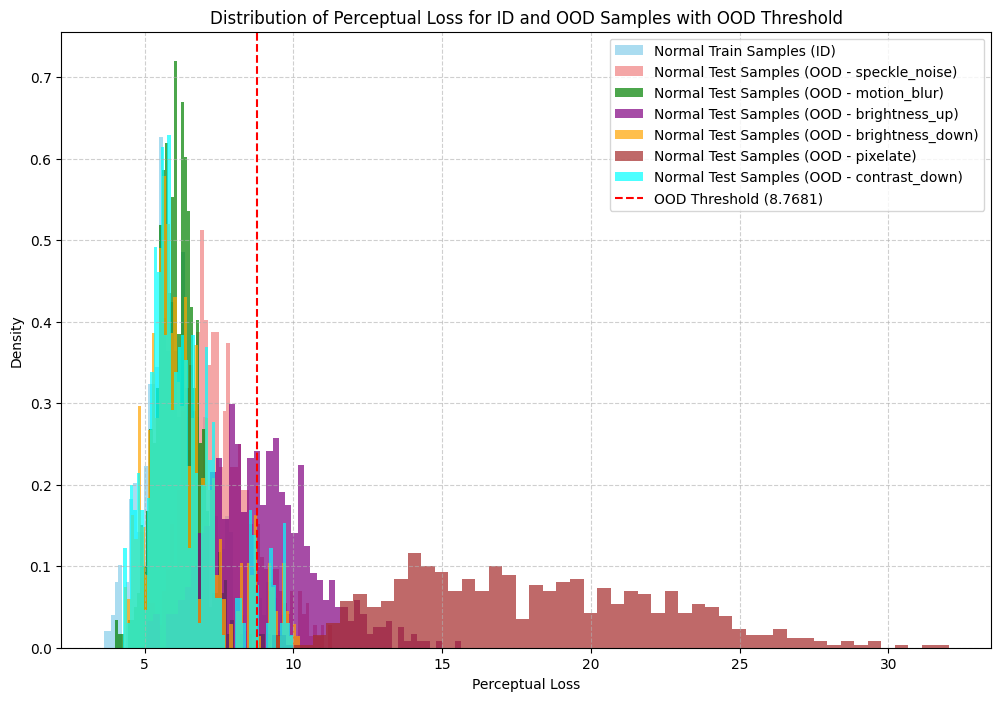

Normal Train Samples (ID) - Mean Perceptual Loss: 6.1689
Normal Train Samples (ID) - Median Perceptual Loss: 5.9688
Normal Train Samples (ID) - Standard Deviation of Perceptual Loss: 1.1914

Perceptual Loss Statistics for Normal Samples in Corrupted Test Datasets (OOD):
  speckle_noise:
    Mean: 7.4834
    Median: 7.3151
    Standard Deviation: 1.1837
  motion_blur:
    Mean: 6.1135
    Median: 6.0697
    Standard Deviation: 0.7103
  brightness_up:
    Mean: 8.9433
    Median: 8.7858
    Standard Deviation: 1.7540
  brightness_down:
    Mean: 6.3316
    Median: 6.0465
    Standard Deviation: 1.2222
  pixelate:
    Mean: 18.0581
    Median: 17.4551
    Standard Deviation: 4.3300
  contrast_down:
    Mean: 6.2814
    Median: 5.9995
    Standard Deviation: 1.2189

Determined OOD Threshold: 8.7681


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'train_perceptual_losses', 'corrupted_losses' dictionary, and 'ood_threshold' are available from previous cell executions

plt.figure(figsize=(12, 8))

# Plot histogram for normal training losses (ID)
plt.hist(train_perceptual_losses, bins=50, density=True, alpha=0.7, color='skyblue', label='Normal Train Samples (ID)')

# Plot histograms for normal samples from each corrupted test dataset (OOD)
colors = ['lightcoral', 'green', 'purple', 'orange', 'brown', 'cyan']
for i, (corruption, losses) in enumerate(corrupted_losses.items()):
    plt.hist(losses, bins=50, density=True, alpha=0.7, color=colors[i % len(colors)], label=f'Normal Test Samples (OOD - {corruption})')

# Add the OOD threshold as a vertical line
plt.axvline(x=ood_threshold, color='red', linestyle='--', label=f'OOD Threshold ({ood_threshold:.4f})')

plt.title('Distribution of Perceptual Loss for ID and OOD Samples with OOD Threshold')
plt.xlabel('Perceptual Loss')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Print statistics for comparison
print(f"Normal Train Samples (ID) - Mean Perceptual Loss: {np.mean(train_perceptual_losses):.4f}")
print(f"Normal Train Samples (ID) - Median Perceptual Loss: {np.median(train_perceptual_losses):.4f}")
print(f"Normal Train Samples (ID) - Standard Deviation of Perceptual Loss: {np.std(train_perceptual_losses):.4f}")

print("\nPerceptual Loss Statistics for Normal Samples in Corrupted Test Datasets (OOD):")
for corruption, losses in corrupted_losses.items():
    print(f"  {corruption}:")
    print(f"    Mean: {np.mean(losses):.4f}")
    print(f"    Median: {np.median(losses):.4f}")
    print(f"    Standard Deviation: {np.std(losses):.4f}")

print(f"\nDetermined OOD Threshold: {ood_threshold:.4f}")